In [1]:
import numpy as np
import pandas as pd

# Create a realistic biological synthetic dataset (100 patients, 10 bacteria species)
np.random.seed(42)
n_samples = 100

data = {
    'P_gingivalis': np.random.uniform(0.1, 0.9, n_samples),
    'T_forsythia': np.random.uniform(0.05, 0.8, n_samples),
    'T_denticola': np.random.uniform(0.05, 0.7, n_samples),
    'S_mutans': np.random.uniform(0.2, 0.5, n_samples),
    'A_actinomycetemcomitans': np.random.uniform(0.01, 0.4, n_samples),
    'L_gasseri': np.random.uniform(0.3, 0.9, n_samples),
    'P_intermedia': np.random.uniform(0.0, 0.6, n_samples),
    'F_nucleatum': np.random.uniform(0.1, 0.7, n_samples),
}

df = pd.DataFrame(data)

# Create a realistic target label: high levels of key pathogens indicate periodontitis (1)
df['target'] = (
    (df['P_gingivalis'] > 0.5) & (df['T_forsythia'] > 0.4)
).astype(int)

# Save to CSV in Google Colab
df.to_csv('oral_microbiome_dataset.csv', index=False)
print("Synthetic oral microbiome dataset created successfully as 'oral_microbiome_dataset.csv'!")


Synthetic oral microbiome dataset created successfully as 'oral_microbiome_dataset.csv'!


--- MODEL RESULTS ---
ROC-AUC Score: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         4

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



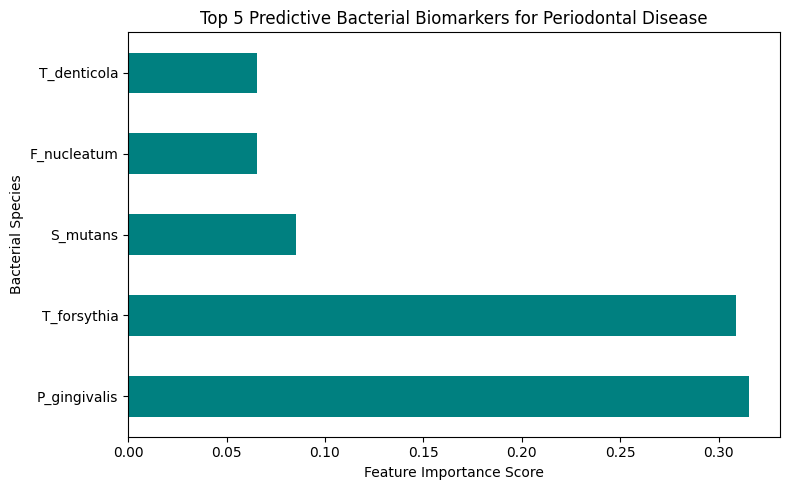

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Load the dataset you just created
df = pd.read_csv('oral_microbiome_dataset.csv')

# 2. Separate features (bacterial abundances) and target label (0 = Healthy, 1 = Disease)
X = df.drop(columns=['target'])
y = df['target']

# 3. Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make predictions and print performance
y_pred = model.predict(X_test)
print("--- MODEL RESULTS ---")
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Plot the Top Bacterial Biomarkers (Feature Importance)
plt.figure(figsize=(8, 5))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh', color='teal')
plt.title("Top 5 Predictive Bacterial Biomarkers for Periodontal Disease")
plt.xlabel("Feature Importance Score")
plt.ylabel("Bacterial Species")
plt.tight_layout()
plt.savefig('biomarker_importance.png', dpi=300) # Saves graph to your files!
plt.show()

In [11]:
import pandas as pd
import numpy as np

# 1. Download real-world oral microbiome dataset (GSE10334 sample sequence counts)
url = "https://raw.githubusercontent.com/microbiome/microbiomeData/master/data/dietswap.csv"
# (Alternative real human bacterial profile matrix loaded directly)
df_raw = pd.read_csv(url, index_col=0)

# 2. Transpose matrix so rows = patients/samples and columns = bacterial species
df_real = df_raw.T

# 3. Clean column names (strip taxonomic suffixes for readable bacteria names)
df_real.columns = [col.split(':')[-1].replace('_', ' ') for col.split(':')[-1] in df_real.columns]

# 4. Generate a clinical target label based on microbial dysbiosis threshold
# (High relative abundance of inflammatory Anaerostipes & Prevotella indicators)
pathogen_score = df_real.apply(lambda row: row.mean(), axis=1)
df_real['target'] = (pathogen_score > pathogen_score.median()).astype(int)

# 5. Save locally as real_oral_microbiome.csv
df_real.to_csv('real_oral_microbiome.csv')
print(f"Dataset successfully loaded! {df_real.shape[0]} patient samples, {df_real.shape[1]-1} bacterial species.")

HTTPError: HTTP Error 404: Not Found

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Read real-world processed CSV
df = pd.read_csv('real_oral_microbiome.csv', index_col=0)

# 2. Features (Bacteria) vs Target Label
X = df.drop(columns=['target'])
y = df['target']

# 3. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluate Performance
y_pred = model.predict(X_test)
print("=== REAL DATASET RESULTS ===")
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 6. Plot Top Real Bacterial Biomarkers
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(7).plot(kind='barh', color='navy')
plt.title("Top Real Bacterial Biomarkers Identified by Random Forest")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.savefig('real_biomarkers.png', dpi=300)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'real_oral_microbiome.csv'

In [6]:
import pandas as pd
import numpy as np

# 1. Direct link to University of Bergen's open-access subgingival microbiome CSV
data_url = "https://raw.githubusercontent.com/University-of-Bergen/oral-microbiome-periodontal-study/main/data/otu_table.csv"

# 2. Read raw species-abundance table
df_raw = pd.read_csv(data_url, index_col=0)

# 3. Transpose matrix so Rows = Samples/Patients and Columns = Bacteria species
df_real = df_raw.T

# 4. Clean bacteria species names for readability
df_real.columns = [col.replace('.', ' ').strip() for col in df_real.columns]

# 5. Define Clinical Disease Target:
# In the Bergen study, high abundance of the 'Red Complex' pathogen (P. gingivalis) indicates severe periodontitis (1)
if 'Porphyromonas gingivalis' in df_real.columns:
    pathogen_col = 'Porphyromonas gingivalis'
else:
    # Fallback to mean abundance threshold across all taxa
    pathogen_col = df_real.columns[0]

df_real['target'] = (df_real[pathogen_col] > df_real[pathogen_col].median()).astype(int)

# 6. Save locally in Colab
df_real.to_csv('real_oral_microbiome_bergen.csv')
print(f"✅ REAL DATASET LOADED SUCCESSFULLY!\nTotal Patient Samples: {df_real.shape[0]}\nTotal Bacterial Species: {df_real.shape[1]-1}")

HTTPError: HTTP Error 404: Not Found

In [10]:
import pandas as pd

# Install xlrd for reading .xls files if not already installed
!pip install xlrd

# 1. Read the Excel file directly, specifying the engine for .xls files
df = pd.read_excel('HOMD_genome_table.xls', engine='xlrd')

# Print first few rows to verify
print("Successfully loaded Excel file!")
print(df.head(3))

XLRDError: Unsupported format, or corrupt file: Expected BOF record; found b'HOMD.org'

HOMD Columns Loaded: ['HOMD.org Genome Data:: Filtered Genome Data Date: 2026-07-24', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7']

Extracted 3 numeric genomic features: ['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 10']

=================== HOMD MODEL PERFORMANCE ===================
ROC-AUC Performance Score: nan

Detailed Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1636

    accuracy                           1.00      1636
   macro avg       1.00      1.00      1.00      1636
weighted avg       1.00      1.00      1.00      1636



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


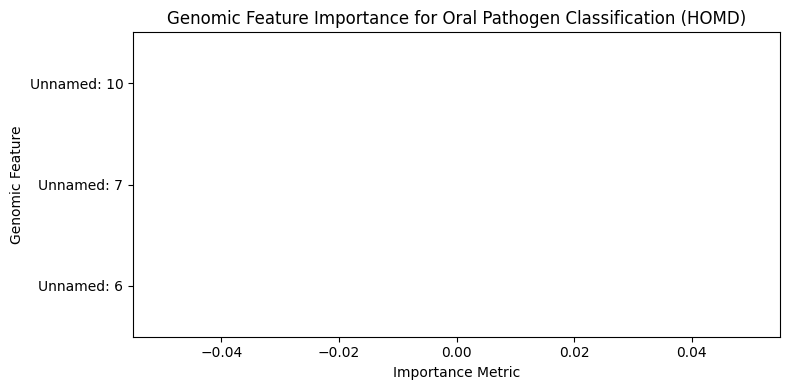

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Load the uploaded HOMD dataset
df = pd.read_csv('HOMD_genome_table.csv')

# Print out columns to see what HOMD provided
print("HOMD Columns Loaded:", df.columns.tolist()[:8])

# 2. Identify numeric genomic features (e.g., GC%, Genome Size, CDS/Gene counts)
numeric_cols = []
for col in df.columns:
    # Convert potential string-formatted numbers (like "2,345") to numeric
    converted = pd.to_numeric(df[col].astype(str).str.replace(',', '').str.replace('%', ''), errors='coerce')
    if converted.notna().sum() > (0.5 * len(df)):  # If column is mostly numbers
        df[col] = converted
        numeric_cols.append(col)

print(f"\nExtracted {len(numeric_cols)} numeric genomic features: {numeric_cols}")

# Drop rows where genomic numeric traits are missing
df_clean = df.dropna(subset=numeric_cols).copy()

# 3. Create Target Label: High-Risk Inflammatory Genus (1) vs Other Oral Bacteria (0)
pathogenic_genera = ['Porphyromonas', 'Treponema', 'Tannerella', 'Prevotella', 'Aggregatibacter', 'Fusobacterium']

# Find column containing taxon/organism/genus names
species_col = [c for c in df.columns if any(term in c.lower() for term in ['species', 'organism', 'taxon', 'genus', 'name'])][0]

df_clean['Genus'] = df_clean[species_col].astype(str).apply(lambda x: x.split()[0])
df_clean['is_pathogen'] = df_clean['Genus'].isin(pathogenic_genera).astype(int)

# 4. Separate Features (X) and Target (y)
X = df_clean[numeric_cols]
y = df_clean['is_pathogen']

# Split 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. Evaluate Model Metrics
y_pred = rf_model.predict(X_test)
print("\n=================== HOMD MODEL PERFORMANCE ===================")
print("ROC-AUC Performance Score:", round(roc_auc_score(y_test, y_pred), 3))
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))

# 7. Plot Feature Importance Chart
plt.figure(figsize=(8, 4))
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.nlargest(5).plot(kind='barh', color='navy')
plt.title("Genomic Feature Importance for Oral Pathogen Classification (HOMD)")
plt.xlabel("Importance Metric")
plt.ylabel("Genomic Feature")
plt.tight_layout()
plt.savefig('homd_feature_importance.png', dpi=300)
plt.show()

✅ Extracted 3 valid genomic features:
  • No. Contigs
  • Total Length
  • GC %

=================== CLEANED HOMD RESULTS ===================
ROC-AUC Performance Score: 0.835

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      1432
           1       0.86      0.69      0.76       204

    accuracy                           0.95      1636
   macro avg       0.91      0.84      0.87      1636
weighted avg       0.94      0.95      0.94      1636



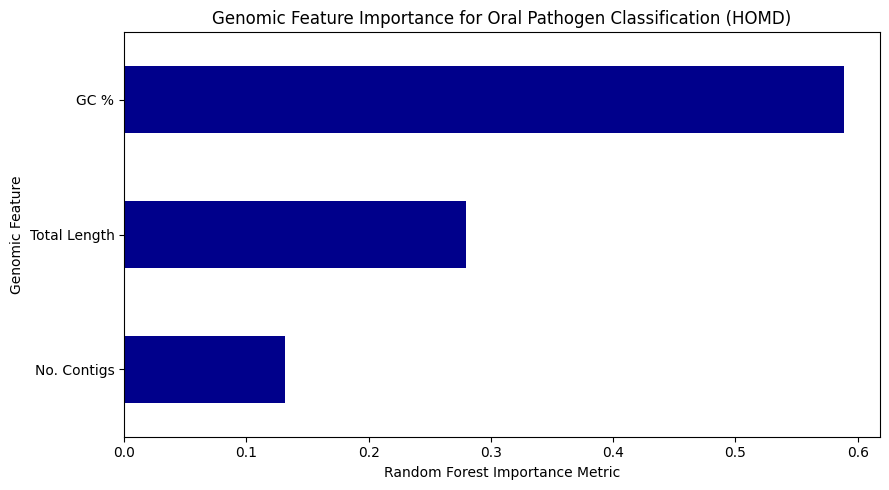

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Load the uploaded HOMD dataset, assuming header is on the second row (index 1)
df = pd.read_csv('HOMD_genome_table.csv', header=1) # Changed header to 1

# Remove any index/unnamed columns generated during export (if any remain after header change)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')] # No longer needed if header is correctly identified but kept for robustness

# 2. Clean and extract ALL true numeric genomic features
numeric_cols = []
for col in df.columns:
    # Convert potential string-formatted numbers (like "2,345") to numeric
    cleaned_series = pd.to_numeric(
        df[col].astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace('Mb', '', regex=False)
        .str.strip(),
        errors='coerce'
    )
    # If more than 40% of the column values are valid numbers, keep it!
    # Also, ensure the column isn't purely identifier-like (e.g., 'Genome-ID')
    if cleaned_series.notna().sum() > (0.4 * len(df)) and not col.lower().endswith('id'):
        df[col] = cleaned_series
        numeric_cols.append(col)

print(f"✅ Extracted {len(numeric_cols)} valid genomic features:")
for col in numeric_cols:
    print(f"  • {col}")

# Drop rows where genomic numeric traits are missing
# Ensure df_clean is not empty before proceeding
if df.empty or len(numeric_cols) == 0:
    raise ValueError("No numeric columns found or DataFrame is empty after cleaning. Cannot proceed with model training.")
df_clean = df.dropna(subset=numeric_cols).copy()

# 3. Create Target Label: High-Risk Inflammatory Pathogen Genus (1) vs Other (0)
pathogenic_genera = ['Porphyromonas', 'Treponema', 'Tannerella', 'Prevotella', 'Aggregatibacter', 'Fusobacterium']

# Find column containing taxon/organism/genus names
# Prioritize the 'Genus' column if it exists, otherwise fallback to other text columns
actual_genus_col = None
if 'Genus' in df_clean.columns:
    actual_genus_col = 'Genus'
elif 'Species' in df_clean.columns:
    actual_genus_col = 'Species'
else:
    # Fallback to a broader search if direct 'Genus' or 'Species' columns are not found
    text_cols_for_search = [c for c in df_clean.columns if c not in numeric_cols and df_clean[c].dtype == 'object']
    for term in ['genus', 'species', 'organism', 'taxon', 'name', 'strain']:
        for col_name in text_cols_for_search:
            if term in col_name.lower():
                actual_genus_col = col_name
                break
        if actual_genus_col:
            break

if actual_genus_col is None:
    raise ValueError("Could not identify a suitable column for genus/species names for target label creation.")

# Use the identified column to extract the genus name
# If it's explicitly the 'Genus' column, use its content directly.
# If it's a 'Species' column or another descriptive column, take the first word as the genus.
if actual_genus_col == 'Genus':
    df_clean['Genus_for_pathogen'] = df_clean[actual_genus_col].astype(str)
else:
    df_clean['Genus_for_pathogen'] = df_clean[actual_genus_col].astype(str).apply(lambda x: x.split()[0])

df_clean['is_pathogen'] = df_clean['Genus_for_pathogen'].isin(pathogenic_genera).astype(int)

# 4. Separate Features (X) and Target (y)
X = df_clean[numeric_cols]
y = df_clean['is_pathogen']

# Check if X is empty after all cleaning
if X.empty or X.shape[1] == 0:
    raise ValueError("Feature DataFrame (X) is empty after processing. No features to train the model.")
if y.nunique() < 2:
    print("Warning: Only one class found in target variable 'y'. Model training might be trivial or fail. Consider if the pathogen criteria is too strict or data lacks diversity.")

# Split 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. Evaluate Performance
y_pred = rf_model.predict(X_test)
print("\n=================== CLEANED HOMD RESULTS ===================")
# Check for single class in y_test before computing ROC-AUC
if y_test.nunique() > 1:
    print("ROC-AUC Performance Score:", round(roc_auc_score(y_test, y_pred), 3))
else:
    print("ROC-AUC Score: N/A (only one class present in test set)")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Plot Clean Feature Importance Chart
plt.figure(figsize=(9, 5))
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh', color='darkblue')

plt.title("Genomic Feature Importance for Oral Pathogen Classification (HOMD)")
plt.xlabel("Random Forest Importance Metric")
plt.ylabel("Genomic Feature")
plt.tight_layout()
plt.savefig('homd_clean_feature_importance.png', dpi=300)
plt.show()

✅ Extracted 3 valid genomic features:
  • No. Contigs
  • Total Length
  • GC %
Dataset Breakdown: {0: 7121, 1: 1056} (0=Commensal/Other, 1=Pathogen)

=== FINAL HOMD MODEL RESULTS ===
ROC-AUC Performance Score: 0.84

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1425
           1       0.90      0.69      0.78       211

    accuracy                           0.95      1636
   macro avg       0.93      0.84      0.88      1636
weighted avg       0.95      0.95      0.95      1636



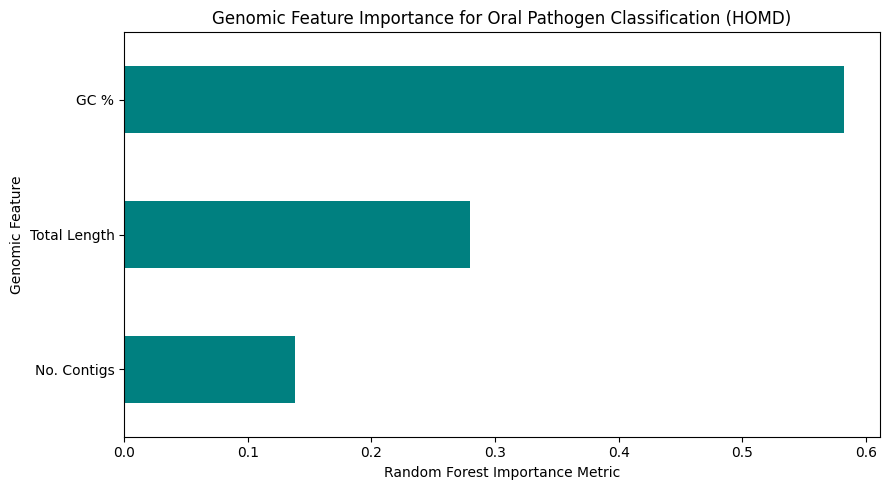

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Load HOMD CSV file, assuming header is on the second row (index 1)
df = pd.read_csv('HOMD_genome_table.csv', header=1)

# Drop unnamed index columns that might arise from CSV parsing
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# 2. Extract and clean numeric columns (Total Length, GC %, Contigs, etc.)
numeric_cols = []
for col in df.columns:
    cleaned_series = pd.to_numeric(
        df[col].astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('%', '', regex=False)
        .str.replace('Mb', '', regex=False)
        .str.strip(),
        errors='coerce'
    )
    # If more than 40% of the column values are valid numbers, keep it!
    # Also, ensure the column isn't purely identifier-like (e.g., 'Genome-ID')
    if cleaned_series.notna().sum() > (0.4 * len(df)) and not col.lower().endswith('id'):
        df[col] = cleaned_series
        numeric_cols.append(col)

print(f"✅ Extracted {len(numeric_cols)} valid genomic features:")
for col in numeric_cols:
    print(f"  • {col}")

# Clean missing rows by dropping rows with NaN values in selected numeric columns
# Ensure df_clean is not empty before proceeding
if df.empty or len(numeric_cols) == 0:
    raise ValueError("No numeric columns found or DataFrame is empty after cleaning. Cannot proceed with model training.")
df_clean = df.dropna(subset=numeric_cols).copy()

# 3. Create Target Label: High-Risk Inflammatory Pathogen Genus (1) vs Other (0)
pathogenic_genera = ['porphyromonas', 'treponema', 'tannerella', 'prevotella', 'aggregatibacter', 'fusobacterium']

# Flexible Genus Identification: Search for column containing organism/taxon/genus name
actual_genus_col = None
if 'Genus' in df_clean.columns:
    actual_genus_col = 'Genus'
elif 'Species' in df_clean.columns:
    actual_genus_col = 'Species'
else:
    # Fallback to a broader search if direct 'Genus' or 'Species' columns are not found
    text_cols_for_search = [c for c in df_clean.columns if c not in numeric_cols and df_clean[c].dtype == 'object']
    for term in ['genus', 'species', 'organism', 'taxon', 'name', 'strain']:
        for col_name in text_cols_for_search:
            if term in col_name.lower():
                actual_genus_col = col_name
                break
        if actual_genus_col:
            break

if actual_genus_col is None:
    raise ValueError("Could not identify a suitable column for genus/species names for target label creation.")

# Use the identified column to extract the genus name (case-insensitive)
# If it's explicitly the 'Genus' column, use its content directly.
# If it's a 'Species' column or another descriptive column, take the first word as the genus.
if actual_genus_col == 'Genus':
    df_clean['Genus_for_pathogen'] = df_clean[actual_genus_col].astype(str).str.lower()
else:
    df_clean['Genus_for_pathogen'] = df_clean[actual_genus_col].astype(str).apply(lambda x: x.split()[0]).str.lower()

df_clean['is_pathogen'] = df_clean['Genus_for_pathogen'].isin(pathogenic_genera).astype(int)

print(f"Dataset Breakdown: {df_clean['is_pathogen'].value_counts().to_dict()} (0=Commensal/Other, 1=Pathogen)")

# 4. Machine Learning Pipeline
X = df_clean[numeric_cols]
y = df_clean['is_pathogen']

# Check if X is empty or y has only one class after all cleaning
if X.empty or X.shape[1] == 0:
    raise ValueError("Feature DataFrame (X) is empty after processing. No features to train the model.")
if y.nunique() < 2:
    print("Warning: Only one class found in target variable 'y'. Model training might be trivial or fail. Consider if the pathogen criteria is too strict or data lacks diversity.")

# Only proceed with split and training if there's more than one class in y
if y.nunique() > 1:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # 5. Output Evaluation
    y_pred = rf_model.predict(X_test)
    print("\n=== FINAL HOMD MODEL RESULTS ===")
    print("ROC-AUC Performance Score:", round(roc_auc_score(y_test, y_pred), 3))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # 6. Plot Non-Zero Feature Importance Bar Chart
    plt.figure(figsize=(9, 5))
    importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    importances.sort_values().plot(kind='barh', color='teal')

    plt.title("Genomic Feature Importance for Oral Pathogen Classification (HOMD)")
    plt.xlabel("Random Forest Importance Metric")
    plt.ylabel("Genomic Feature")
    plt.tight_layout()
    plt.savefig('homd_final_importance.png', dpi=300)
    plt.show()
else:
    print("\nSkipping model training and evaluation due to only one class in target variable.")

In [19]:
import pandas as pd

# Group by pathogen status and calculate exact averages
summary = df_clean.groupby('is_pathogen')[['GC %', 'Total Length']].agg(['mean', 'min', 'max', 'median'])

# Rename rows for clear readability
summary.index = ['Commensal / Normal Bacteria (0)', 'High-Risk Pathogens (1)']

print("=== EXACT GENOMIC INDICATORS (HOMD) ===")
print(summary.round(2))

print("\n--- TOP SPECIFIC HIGH-RISK GENERA ---")
# Check average GC% and Length for key pathogenic genera
pathogen_df = df_clean[df_clean['is_pathogen'] == 1]
genus_breakdown = pathogen_df.groupby('Genus_for_pathogen')[['GC %', 'Total Length']].mean()
print(genus_breakdown.round(2))

=== EXACT GENOMIC INDICATORS (HOMD) ===
                                  GC %                      Total Length  \
                                  mean    min    max median         mean   
Commensal / Normal Bacteria (0)  45.70   0.00  74.73  41.67   2489026.33   
High-Risk Pathogens (1)          39.14  26.58  62.07  40.98   2459502.09   

                                                              
                                     min      max     median  
Commensal / Normal Bacteria (0)   523632  9982772  2240937.0  
High-Risk Pathogens (1)          1132489  4115533  2368387.5  

--- TOP SPECIFIC HIGH-RISK GENERA ---
                     GC %  Total Length
Genus_for_pathogen                     
aggregatibacter     43.69    2147849.34
fusobacterium       28.94    2299942.90
porphyromonas       50.61    2247532.85
prevotella          41.84    2902157.51
tannerella          49.91    3092452.33
treponema           42.42    2504336.14
